In [44]:
#set the environment variable for Groq API key
import os

if "GROQ_API_KEY" not in os.environ:
    print("Warning: GROQ_API_KEY environment variable not set")


In [45]:
#Now llm setup
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)
response = llm.invoke("What is the capital of France?").content
print(response)


The capital of France is Paris.


In [46]:
#Graph schema 
from typing import List, Annotated, TypedDict
from langgraph.graph.message import add_messages

 
class Graph_Schema(TypedDict):
    messages: Annotated[List,add_messages]

In [47]:
#create node function

def node_func(state : Graph_Schema) -> Graph_Schema:

    messages = state["messages"]
    response = llm.invoke(messages).content
    state["messages"] = f"Your message was:{messages}.Here is my reponse: {response}"
    return state

In [48]:
#define a state graph

from langgraph.graph import StateGraph,START,END

graph = StateGraph(Graph_Schema)
graph.add_node("node_func",node_func)
graph.add_edge(START,"node_func")
graph.add_edge("node_func",END)


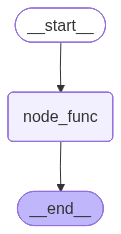

In [49]:
#compile the graph
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import  display,Image

checkpointer = InMemorySaver()
memory_graph = graph.compile(checkpointer=checkpointer)

Image(memory_graph.get_graph().draw_mermaid_png())

In [51]:
#Run the graph
from langchain_core.messages import HumanMessage

response = memory_graph.invoke(
    {"messages" : [HumanMessage(content="what is my name?")]},
    {"configurable" : {"thread_id" : "sandip"}}
)

for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

my name is sandip
================================ Human Message =================================

Your message was:[HumanMessage(content='my name is sandip', additional_kwargs={}, response_metadata={}, id='3e94b8b0-b628-4f89-8a1f-6006279d5c5e')].Here is my reponse: Nice to meet you, Sandip. Is there something I can help you with today?
================================ Human Message =================================

what is my name?
================================ Human Message =================================

Your message was:[HumanMessage(content='my name is sandip', additional_kwargs={}, response_metadata={}, id='3e94b8b0-b628-4f89-8a1f-6006279d5c5e'), HumanMessage(content="Your message was:[HumanMessage(content='my name is sandip', additional_kwargs={}, response_metadata={}, id='3e94b8b0-b628-4f89-8a1f-6006279d5c5e')].Here is my reponse: Nice to meet you, Sandip. Is there something I can help you